# 01 — v1 baseline recurrent leak-free

Objetivo: construir una **línea base sencilla, reproducible y metodológicamente limpia** para predecir el latido objetivo en MIT-BIH usando únicamente una red recurrente.

Decisiones clave de v1:
- entrada: **secuencia HRV causal**
- modelo: **GRU unidireccional pequeña**
- split: **grouped por `record_id`**
- desbalance: **class weights**
- XAI: **saliency + integrated gradients + occlusion**

In [12]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import tensorflow as tf

from src.utils.reproducibility import set_global_seed
from src.features.sequence_builders import SequenceBuildConfig, build_dual_branch_dataset
from src.data.splits import make_fixed_grouped_splits
from src.features.preprocessing import fit_sequence_scaler
from src.training.train import TrainingConfig, fit_model
from src.evaluation.metrics import build_evaluation_bundle
from src.evaluation.reporting import plot_confusion, plot_training_history, measure_inference_time
from src.xai.gradients import saliency_map, integrated_gradients
from src.xai.occlusion import temporal_occlusion_importance
from src.utils.io import save_json, save_joblib

## Configuración experimental

En esta versión evitamos cualquier artificio que pueda inflar métricas:
- no hay `validation_split`
- no hay SMOTE
- no hay mezcla de ventanas del mismo registro entre conjuntos

In [13]:
set_global_seed(42)

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "mit-bih-arrhythmia-database-1.0.0"
OUTPUT_DIR = PROJECT_ROOT / "models" / "v1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_CFG = SequenceBuildConfig(
    data_dir=str(DATA_DIR),
    label_mode="aami_5",
    n_steps=15,
    horizon=1,
    lead=0,
    beat_window_before=90,
    beat_window_after=162,
    exclude_paced_records=False,
)

TRAIN_CFG = TrainingConfig(
    model_version="v1",
    batch_size=128,
    epochs=50,
    learning_rate=1e-3,
    clipnorm=1.0,
    balance_strategy="class_weights",
    patience=8,
    lr_patience=3,
    checkpoint_path=str(OUTPUT_DIR / "model.keras"),
    random_state=42,
    model_kwargs={
        "rnn_type": "gru",
        "units": 48,
        "dense_units": 32,
        "dropout_rate": 0.2,
        "recurrent_dropout_rate": 0.1,
        "l2_reg": 1e-4,
    },
)

In [14]:
dataset = build_dual_branch_dataset(DATA_CFG)
X_hrv = dataset["X_hrv"]
y = dataset["y"]
groups = dataset["groups"]
meta = dataset["meta"]
class_names = {int(k): v for k, v in dataset["class_names"].items()}

print("X_hrv:", X_hrv.shape)
print("y:", y.shape)
print("Registros únicos:", len(np.unique(groups)))
print(pd.Series(y).value_counts().sort_index())

X_hrv: (108726, 15, 8)
y: (108726,)
Registros únicos: 48
0    89982
1     2771
2     7193
3      801
4     7979
Name: count, dtype: int64


In [15]:
split = make_fixed_grouped_splits(y=y, groups=groups, seed=42)

X_train_raw = X_hrv[split.train_idx]
X_val_raw = X_hrv[split.val_idx]
X_test_raw = X_hrv[split.test_idx]

y_train = y[split.train_idx]
y_val = y[split.val_idx]
y_test = y[split.test_idx]

groups_train = groups[split.train_idx]
groups_val = groups[split.val_idx]
groups_test = groups[split.test_idx]

assert set(groups_train).isdisjoint(set(groups_val))
assert set(groups_train).isdisjoint(set(groups_test))
assert set(groups_val).isdisjoint(set(groups_test))

print("Train groups:", len(set(groups_train)))
print("Val groups:", len(set(groups_val)))
print("Test groups:", len(set(groups_test)))

Train groups: 28
Val groups: 11
Test groups: 9


In [16]:
scaler_hrv = fit_sequence_scaler(X_train_raw, scaler_name="robust")

X_train = scaler_hrv.transform(X_train_raw)
X_val = scaler_hrv.transform(X_val_raw)
X_test = scaler_hrv.transform(X_test_raw)

save_joblib(scaler_hrv, OUTPUT_DIR / "scaler_hrv.joblib")

WindowsPath('c:/Users/jordi/Documents/UNI/TrabajoRNN/models/v1/scaler_hrv.joblib')

In [17]:
model, history = fit_model(
    x_train=X_train,
    y_train=y_train,
    x_val=X_val,
    y_val=y_val,
    cfg=TRAIN_CFG,
    input_shapes={"sequence_input": X_train.shape[1:]},
    num_classes=len(class_names),
)

Epoch 1/50
485/486 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3720 - loss: 1.0092
Epoch 1: val_loss improved from None to 1.37663, saving model to c:\Users\jordi\Documents\UNI\TrabajoRNN\models\v1\model.keras
486/486 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4539 - loss: 0.8622 - val_accuracy: 0.3578 - val_loss: 1.3766 - learning_rate: 0.0010
Epoch 2/50
478/486 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5224 - loss: 0.7220
Epoch 2: val_loss improved from 1.37663 to 1.29785, saving model to c:\Users\jordi\Documents\UNI\TrabajoRNN\models\v1\model.keras
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5265 - loss: 0.7371 - val_accuracy: 0.4196 - val_loss: 1.2979 - learning_rate: 0.0010
Epoch 3/50
482/486 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5314 - loss: 0.6890
Epoch 3: val_loss did not improve from 1.29785
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5352 - loss: 0.7072 - val_accuracy: 0.3783 - val_loss: 1.3829 - learning_rate: 0.0010
Epoch 4/50
480/

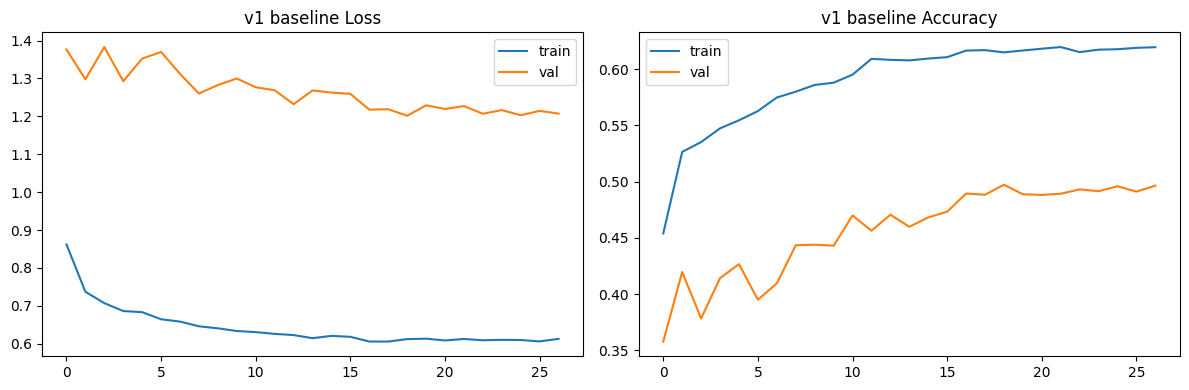

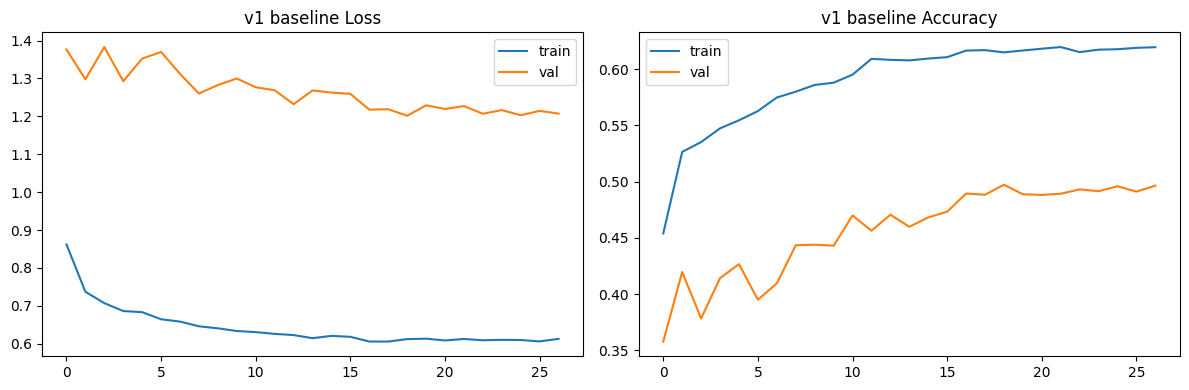

In [18]:
fig = plot_training_history(history, title_prefix="v1 baseline")
fig

In [19]:
y_test_prob = model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

eval_bundle = build_evaluation_bundle(
    y_true=y_test,
    y_pred=y_test_pred,
    y_prob=y_test_prob,
    class_names=class_names,
)
eval_bundle["inference_time"] = measure_inference_time(model, X_test[:1], repeats=20)

eval_bundle["global_metrics"]

{'accuracy': 0.6343893205817892,
 'macro_f1': 0.34443814201451983,
 'weighted_f1': 0.6842174771298103,
 'macro_precision': 0.32663486773532097,
 'macro_recall': 0.4555586715239503,
 'macro_ovr_roc_auc': 0.6671075215079793}

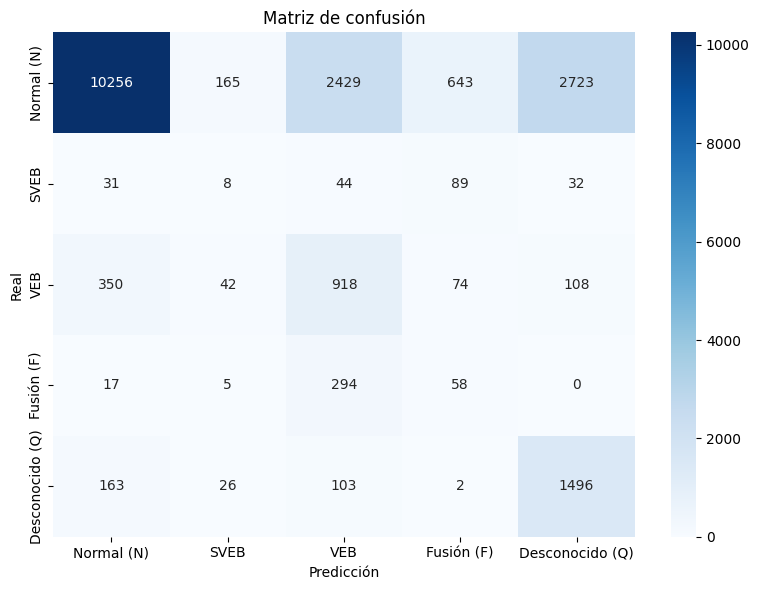

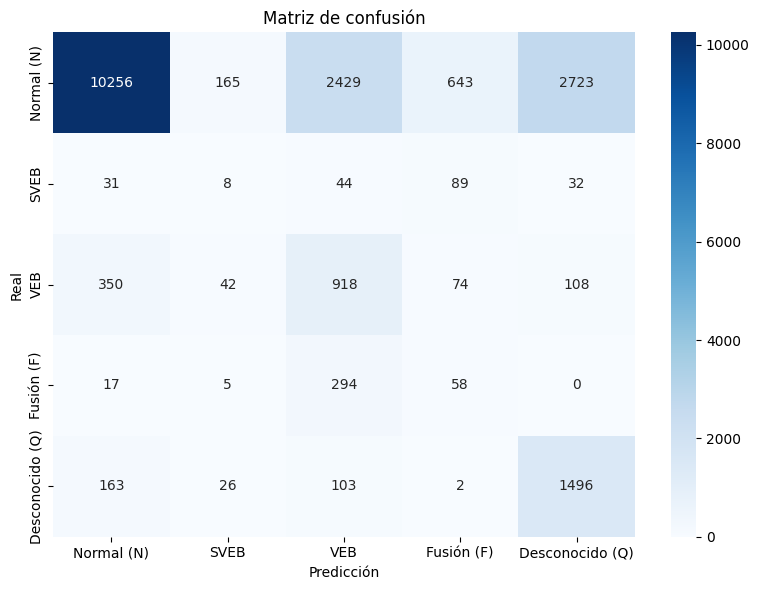

In [20]:
plot_confusion(y_test, y_test_pred, class_names, normalize=False)

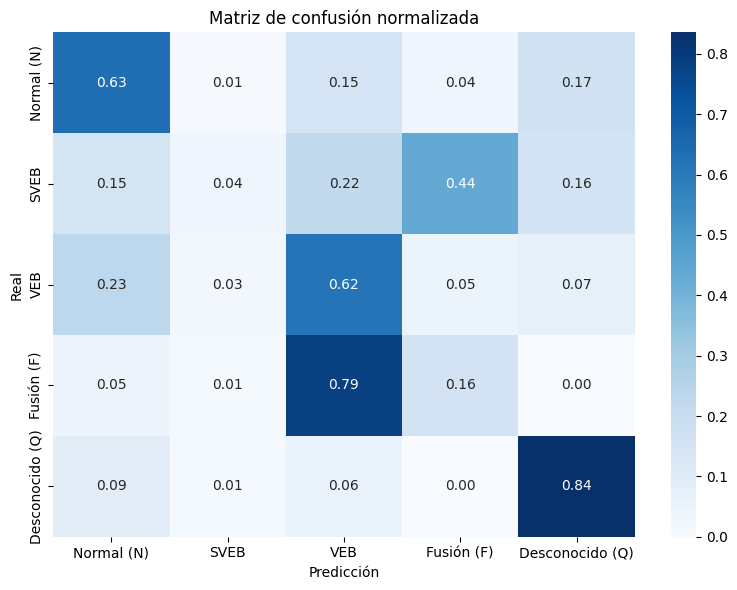

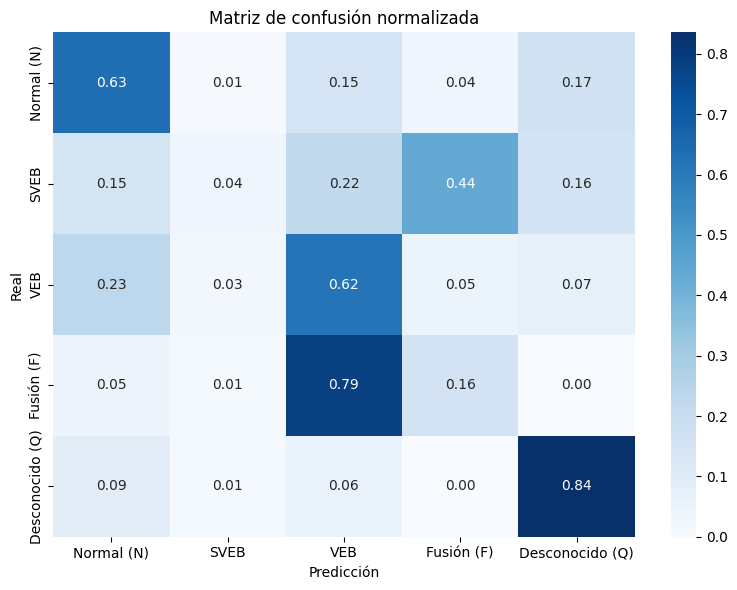

In [21]:
plot_confusion(y_test, y_test_pred, class_names, normalize=True)

## Guardado de artefactos

Guardamos:
- modelo
- scaler
- metadata
- métricas de test

In [22]:
metadata = {
    "model_version": "v1",
    "task": "next_beat_aami5_grouped",
    "class_names": class_names,
    "input_shapes": {"sequence_input": list(X_train.shape[1:])},
    "feature_names": dataset["feature_names_hrv"],
    "split_protocol": "grouped_stratified_record_split",
    "balance_strategy": TRAIN_CFG.balance_strategy,
    "loss_name": TRAIN_CFG.loss_name,
    "seed": TRAIN_CFG.random_state,
    "data_config": dataset["config"],
}

model.save(OUTPUT_DIR / "model.keras")
save_json(metadata, OUTPUT_DIR / "metadata.json")
save_json(eval_bundle, OUTPUT_DIR / "metrics_test.json")

WindowsPath('c:/Users/jordi/Documents/UNI/TrabajoRNN/models/v1/metrics_test.json')

## XAI mínima pero útil

La idea no es “leer la mente” del modelo, sino inspeccionar:
- qué **timesteps** pesan más
- qué rasgos HRV acumulan más atribución
- si la relevancia temporal parece fisiológicamente plausible

In [23]:
sample_idx = 0
sample = X_test[sample_idx:sample_idx+1]

sample_saliency = saliency_map(model, sample)
sample_ig = integrated_gradients(model, sample, steps=32)
sample_occ = temporal_occlusion_importance(model, sample, window=1)

print("Saliency shape:", sample_saliency.shape)
print("IG shape:", sample_ig.shape)
print("Occlusion shape:", sample_occ.shape)

Saliency shape: (1, 15, 8)
IG shape: (1, 15, 8)
Occlusion shape: (15,)


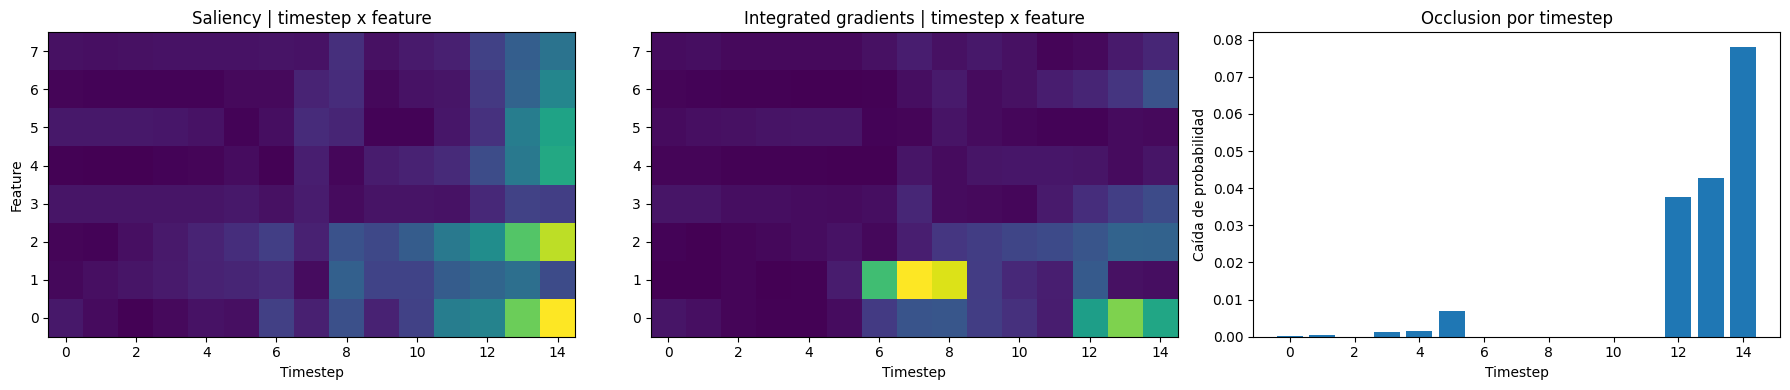

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].imshow(np.abs(sample_saliency[0]).T, aspect="auto", origin="lower")
axes[0].set_title("Saliency | timestep x feature")
axes[0].set_xlabel("Timestep")
axes[0].set_ylabel("Feature")

axes[1].imshow(np.abs(sample_ig[0]).T, aspect="auto", origin="lower")
axes[1].set_title("Integrated gradients | timestep x feature")
axes[1].set_xlabel("Timestep")

axes[2].bar(np.arange(len(sample_occ)), sample_occ)
axes[2].set_title("Occlusion por timestep")
axes[2].set_xlabel("Timestep")
axes[2].set_ylabel("Caída de probabilidad")

plt.tight_layout()
plt.show()

## Cierre v1

Esta baseline debe servir como referencia honesta. Si una versión posterior mejora, la mejora tiene que sostenerse sobre este protocolo limpio, no sobre un split contaminado.